In [1]:
import os
import random
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
print("Current working directory:", os.getcwd())
print("Librosa version:", librosa.__version__)

Current working directory: /Users/sharathsubramanian/audio-deepfake-detector/notebooks
Librosa version: 0.11.0


In [3]:
data_dir = "../data/ASVspoof2019_LA"

train_audio_dir = f"{data_dir}/ASVspoof2019_LA_train/flac"
dev_audio_dir = f"{data_dir}/ASVspoof2019_LA_dev/flac"

train_protocol = f"{data_dir}/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.train.trn.txt"
dev_protocol = f"{data_dir}/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.dev.trl.txt"

print("Paths set successfully!")

Paths set successfully!


In [4]:
print("Train dir exists:", os.path.exists(train_audio_dir))
print("Dev dir exists:", os.path.exists(dev_audio_dir))
print("Train protocol exists:", os.path.exists(train_protocol))
print("Dev protocol exists:", os.path.exists(dev_protocol))

Train dir exists: True
Dev dir exists: True
Train protocol exists: True
Dev protocol exists: True


In [5]:
def load_protocol(file_path):
    data = []
    
    with open(file_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            
            file_name = parts[1]
            label = parts[-1]
            
            label = 0 if label == "bonafide" else 1
            
            data.append((file_name, label))
    
    return data

train_data = load_protocol(train_protocol)
dev_data = load_protocol(dev_protocol)

print("Train samples:", len(train_data))
print("Dev samples:", len(dev_data))

Train samples: 25380
Dev samples: 24844


In [6]:
random.shuffle(train_data)
random.shuffle(dev_data)

train_subset = train_data[:1000]
dev_subset = dev_data[:500]

print("Subset created!")
print("Train subset:", len(train_subset))
print("Dev subset:", len(dev_subset))

Subset created!
Train subset: 1000
Dev subset: 500


In [7]:
sample_file, label = train_subset[0]

audio_path = f"{train_audio_dir}/{sample_file}.flac"

y, sr = librosa.load(audio_path, sr=16000)

print("Loaded file:", sample_file)
print("Label:", "Real" if label == 0 else "Fake")
print("Shape:", y.shape)
print("Sample rate:", sr)

Loaded file: LA_T_3509843
Label: Fake
Shape: (74057,)
Sample rate: 16000


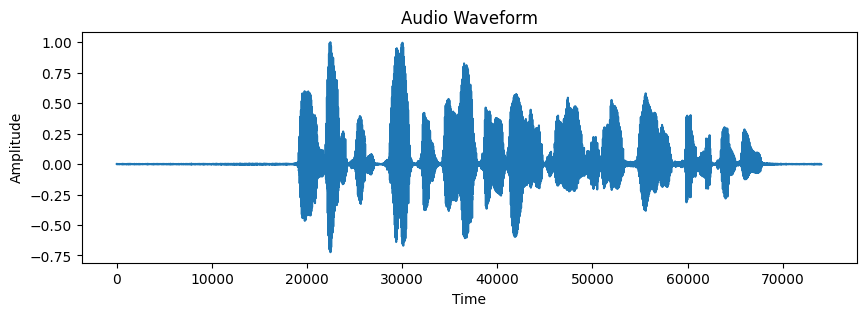

In [8]:
plt.figure(figsize=(10, 3))
plt.plot(y)
plt.title("Audio Waveform")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.show()

In [9]:
mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

print("Spectrogram shape:", mel_spec_db.shape)

Spectrogram shape: (128, 145)


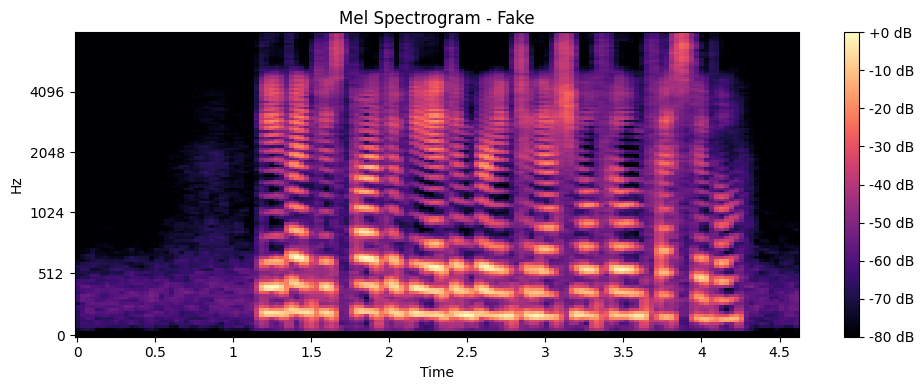

In [10]:
plt.figure(figsize=(10, 4))
librosa.display.specshow(mel_spec_db, sr=sr, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title(f"Mel Spectrogram - {'Real' if label == 0 else 'Fake'}")
plt.tight_layout()
plt.show()

In [11]:
print("Setup notebook completed successfully!")
print("Dataset loaded, processed, and visualized.")

Setup notebook completed successfully!
Dataset loaded, processed, and visualized.


In [12]:
# Count real vs fake
labels = [label for _, label in train_subset]

real_count = labels.count(0)
fake_count = labels.count(1)

print("Real samples:", real_count)
print("Fake samples:", fake_count)

Real samples: 97
Fake samples: 903
